# MensaFetcher — Datenexploration & Visualisierung

Dieses Notebook zeigt schnelle Beispiele, wie die Snapshots in der SQLite‑DB geladen
und zur Analyse mit `pandas` aufbereitet werden können.

Benutze `scripts.analysis_utils` für wiederverwendbare Helper‑Funktionen.

**Datenbank:** 277 Snapshots, täglich 2 Versuche (attempt 1 & 2), ~100+ Gerichte pro Snapshot.

In [3]:
# Import und Verbindung herstellen
import sys
import os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

# Force reload of the module to pick up new functions
import importlib
if 'scripts.analysis_utils' in sys.modules:
    importlib.reload(sys.modules['scripts.analysis_utils'])

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from scripts.analysis_utils import (
    open_conn,
    list_snapshots,
    export_snapshot_to_pandas,
    get_snapshot_entries,
    get_dish_timeseries,
    get_tags_distribution_timeseries,
)

# Pfad zur lokalen DB anpassen falls nötig
DB_PATH = '../data/mensa_260511.db'
conn = open_conn(DB_PATH)
print('✓ Connected to', DB_PATH)

✓ Connected to ../data/mensa_260511.db


## Schritt 1: Trockene Zahlen 

In [ ]:
q = """
    SELECT canonical_hash, name, description
    FROM dish
    """
rows = conn.execute(q).fetchall()
dish_df = pd.DataFrame([dict(r) for r in rows])
print(f"Anzahl Gerichte: {len(dish_df)}")
print(f"Anzahl unterschiedlicher Gerichte (nach Namen): {len(dish_df.groupby(["name"]))}")

Anzahl Gerichte: 929
Anzahl unterschiedlicher Gerichte (nach Namen): 660
                                            count unique  \
name                                                       
2 Back-Camenbert,Preiselbeercreme               1      1   
2 Gemüse-Knusper-Bagel                          1      1   
2 Gemüse-Knusper-Bagel,Ratatouille              2      1   
2 Kohlrabi Kräuter Medaillons ,Sauerrahmdip     1      1   
2 Kohlrabi Kräuter Medaillons oder              1      1   

                                                                                           top  \
name                                                                                             
2 Back-Camenbert,Preiselbeercreme                      gebackene Kartoffelscheiben Schmorkraut   
2 Gemüse-Knusper-Bagel                            Ratatouille-Gemüse mediterranes Gemüsebulgur   
2 Gemüse-Knusper-Bagel,Ratatouille                                   mediterranes Gemüsebulgur   
2 Kohlrabi Kräut

## Schritt 6: Zeitreihen — Empties über Zeit

In [4]:
# Lade empties_count Zeitreihe aus allen Snapshots
q = "SELECT date, attempt, empties_count FROM snapshot ORDER BY date, attempt"
rows = conn.execute(q).fetchall()
ts_df = pd.DataFrame([dict(r) for r in rows])
ts_df['date'] = pd.to_datetime(ts_df['date'], errors='coerce')
ts_df = ts_df.dropna(subset=['date'])

print(f'Zeitreihe mit {len(ts_df)} Einträgen')
print(ts_df.tail())

Zeitreihe mit 277 Einträgen
          date  attempt  empties_count
272 2026-05-09        1              0
273 2026-05-09        2              0
274 2026-05-10        1              0
275 2026-05-10        2              0
276 2026-05-11        1              0


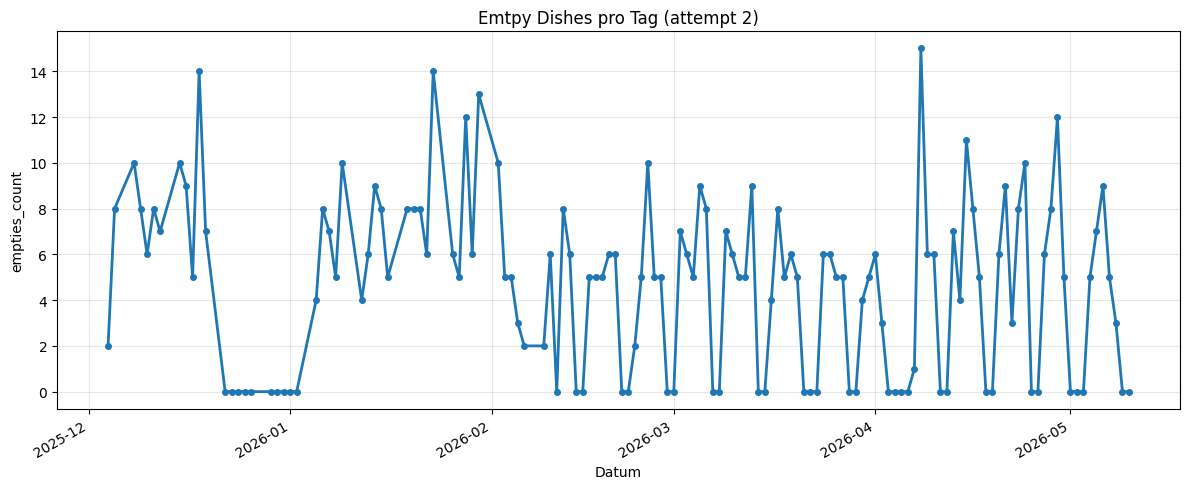


Empties Statistik (attempt 2):
  Mean: 4.6
  Max:  15
  Min:  0


In [5]:
# Plot: Empties über Zeit
fig, ax = plt.subplots(figsize=(12, 5))

# Nur attempt 2 (wo empties_count berechnet wird)
attempt2 = ts_df[ts_df['attempt'] == 2].sort_values('date')
ax.plot(attempt2['date'], attempt2['empties_count'].fillna(0).astype(int), marker='o', linestyle='-', linewidth=2, markersize=4)
ax.set_title('Emtpy Dishes pro Tag (attempt 2)')
ax.set_xlabel('Datum')
ax.set_ylabel('empties_count')
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Statistiken
print(f"\nEmpties Statistik (attempt 2):")
print(f"  Mean: {attempt2['empties_count'].mean():.1f}")
print(f"  Max:  {attempt2['empties_count'].max():.0f}")
print(f"  Min:  {attempt2['empties_count'].min():.0f}")

# Schritt 9: Anteile Vegetarisch, Vegan im Zeitverlauf

In [9]:
# Analysiere V/VG-Anteile über die gesamte Zeit (nur attempt 1)
# Zähle pro Tag die Anzahl Gerichte mit VG, V oder neither (über alle Gerichte)
tag_ts = get_tags_distribution_timeseries(conn, attempt=1)

if not tag_ts.empty:
    tag_ts['date'] = pd.to_datetime(tag_ts['date'])
    tag_ts = tag_ts.sort_values('date')
    
    # Explodiere tags
    tag_exploded = tag_ts.explode('tags')
    
    # Aggregate tags per dish+date and decide label (prefer VG if both)
    tag_sets = (
        tag_exploded
        .groupby(['date', 'canonical_hash'])['tags']
        .agg(lambda s: set([t for t in s if pd.notna(t)]))
        .reset_index()
    )

    def _label(ts):
        if 'VG' in ts:
            return 'VG'
        if 'V' in ts:
            return 'V'
        return 'neither'

    tag_sets['veg_label'] = tag_sets['tags'].apply(_label)

    # Zähle pro Tag die Anzahl Gerichte mit VG, V oder neither
    veg_counts = tag_sets.groupby('date')['veg_label'].value_counts().unstack(fill_value=0)

    # Sicherstellen, dass die Spalten in konsistenter Reihenfolge vorhanden sind
    for col in ['VG', 'V', 'neither']:
        if col not in veg_counts.columns:
            veg_counts[col] = 0
    veg_counts = veg_counts[['VG', 'V', 'neither']]
    print(f'\nAnzahl Gerichte mit V/VG pro Tag (attempt 1, alle Gerichte):')
    print(veg_counts)


Anzahl Gerichte mit V/VG pro Tag (attempt 1, alle Gerichte):
veg_label   VG  V  neither
date                      
2025-12-04   2  4       12
2025-12-05   1  5       13
2025-12-08   2  3       13
2025-12-09   2  3       15
2025-12-10   2  2       15
...         .. ..      ...
2026-05-07   2  5       12
2026-05-08   3  5        8
2026-05-09   0  2        5
2026-05-10   0  2        5
2026-05-11   2  5       12

[134 rows x 3 columns]


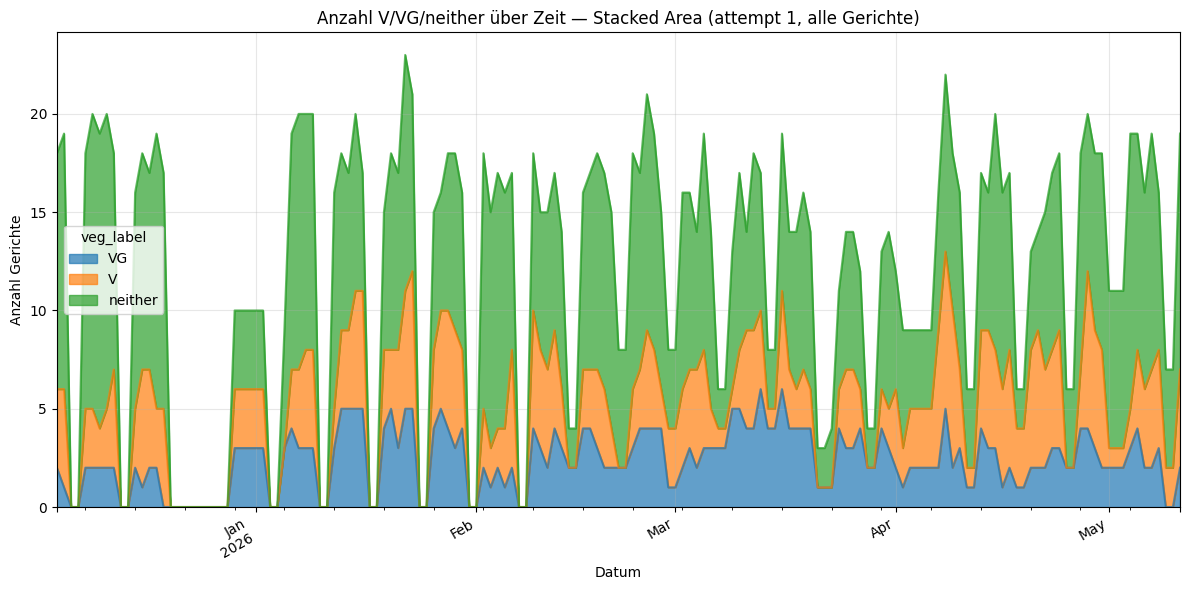

In [10]:
# Plot: Stacked Area Chart V/VG/neither über Zeit (alle Gerichte)
if not veg_counts.empty:
    # insert empty rows for missing dates to avoid misleading connections in the area plot
    veg_counts = veg_counts.asfreq('D', fill_value=0)
    fig, ax = plt.subplots(figsize=(12, 6))
    veg_counts.plot(kind='area', stacked=True, ax=ax, alpha=0.7)
    ax.set_title(f'Anzahl V/VG/neither über Zeit — Stacked Area (attempt 1, alle Gerichte)')
    ax.set_xlabel('Datum')
    ax.set_ylabel('Anzahl Gerichte')
    ax.grid(True, alpha=0.3)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()